In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from econml.dml import DML
from econml.dr import DRLearner
from econml.sklearn_extensions.linear_model import StatsModelsLinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor

### Prepare data
* lowercase column names
* ensure datetime dtype
* lose order_day (date) for duration (years) since 2017
* drop unnecessary columns
* impute missing values
* encode treatment properly

In [24]:
data.columns

Index(['icd_metastsolidtumor_1m', 'lab_platelets', 'icd_periphvasdis_2y',
       'enc_community', 'lab_carbon_dioxide', 'icd_drugs_2y',
       'icd_congheartfailure_2y', 'icd_psychoses_2y', 'lab_pct_basophils',
       'icd_cellulitis_1w', 'lab_anion_gap', 'icd_mildliverdis_2y',
       'enc_nursing_home_hospice', 'lab_hematocrit', 'icd_peritonitis_1w',
       'female', 'lab_abs_monocytes', 'lab_glucose', 'icd_weightloss_2y',
       'lab_sodium', 'enc_regional', 'icd_malignancy_1m', 'lab_egfr',
       'lab_creatinine', 'icd_alcohol_2y', 'icd_endocarditis_1w',
       'icd_respiratory_1w', 'icd_renaldis_2y', 'icd_dementia_2y', 'lab_rbc',
       'lab_pct_eosinophils', 'lab_pct_neutrophils', 'lab_mcv',
       'icd_hypothyroid_2y', 'lab_abs_neutrophils', 'icd_ondialysis_2y',
       'icd_cpd_1m', 'time', 'enc_hosp_acq', 'enc_mercy', 'enc_presbyterian',
       'enc_childrens', 'icd_osteochronic_2y', 'icd_aids_hiv_2y',
       'icd_malignancy_2y', 'icd_modsevlivdis_2y', 'icd_sepsis_1w', 'lab_mch'

In [ ]:
# df['order_day'] = pd.to_datetime(df.order_day)
# df['time'] = df.order_day.apply(lambda x: (x - pd.Timestamp('2017-01-01 00:00:00')).total_seconds() / (24 * 60 * 60 * 365))

# # re-encode facility names into meaningful groups
# df['academic'] = df.enc_facility1.isin(['Presbyterian', 'Mercy', 'Shadyside', 'Magee-W']).astype(int)
# df['regional'] = df.enc_facility1.isin(['Hamot', 'Williamsport', 'Jameson', 'Altoona']).astype(int)
# df['community'] = df.enc_facility1.isin(['Passavant', 'East', 'McKeesport', 'St. Margaret', 'SOL']).astype(int)
# df['rural'] = df.enc_facility1.isin(['Bedford', 'Northwest', 'Horizon', 'Chatauqua', 'LOC']).astype(int)

# # choose outcome variable and rename column
# outcome_var = 'd30mortality'
# df['outcome'] = df[outcome_var]

# # drop unnecessary columns
# df = df.loc[:, ~df.columns.str.contains('^respiratory_[^i]')] # remove respiratory isolate pathogen names
# df = df.drop(labels = ['empdisc', 'defdisc', 'order_day', 'person_id', 'enc_facility1', 'enc_facility2'], axis=1)
# df = df.loc[:, ~df.columns.str.contains('.+_time$|d[0-9]+')]
# df = df.drop('total_los', axis=1)

#### Handle cohort:
* MRSA, at least 2 days 

In [211]:
data = df[(df.mrsa == 1) & (df.van_def + df.dap_def >= 2) & (df.respiratory_isolate != 1)]
data.loc[:, 'van_def'] = (data.van_def >= 1).astype(int)
data.loc[:, 'dap_def'] = (data.dap_def >= 1).astype(int)
# encode VAN and DAP accordingly
data['treatment'] = 'van'
data.loc[(data.van_def == 0) & (data.dap_def == 1), 'treatment'] = 'idap'
data.loc[(data.van_def == 1) & (data.dap_def == 1), 'treatment'] = 'sdap'

 # get rid of rest of treatment variables
data = data.loc[:, ~data.columns.str.contains('.+_(?:emp|def)$', regex=True)]
exclude_vars = [
    'respiratory_isolate', 'enc_maternal', 'time_to_conc', 
    'mrsa', 'vre', 'esbl', 'mdr_pseud', 'enterobacterales', 'nonfermgn', 'enterococci', 'streptococci', 'staphylococci', 
    'icd_peritonitis_1w', 'icd_respiratory_1w'
]
data = data.drop(exclude_vars, axis=1)


# # Impute missing values (lab results) - need to do if not using ML models that can handle missing values
# missing_vars = data.columns[data.isna().any()].tolist()
# data[missing_vars] = data[missing_vars].apply(lambda x: x.fillna(x.mean()))
data['treatment'] = (data['treatment'] != 'van').astype(int)

W = data.drop(['outcome', 'treatment'], axis=1) # consider every non-Y variable as a potential confounder (or "control" variable as econml documentation says)
features = [
    'age', 'female', 'time',
    #'academic', 'regional', 'community', 'rural', 
    'enc_hosp_acq', 'enc_nursing_home_hospice', 'enc_emergency_dept', 'enc_transfer',
    'icd_sepsis_1w', 'icd_aki_1w', 'icd_endocarditis_1w', 'icd_osteomyelitis_1w', 'icd_cellulitis_1w'
]
pd.Series(features).to_csv('~/Desktop/EHR-mining/Scripts/AnalysisScripts/R01/ITE/features.csv', index=False, header=False)
# features.extend(data.columns[data.columns.str.contains('icd')].to_list())
X = data.loc[:, features]
Y = data['outcome']
T = data['treatment']


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [108]:
# data = pd.read_csv('~/Desktop/EHR/EHR work/RdataFiles/BuildCohortDatasets/mrsa_modded_2017_2023_bacteremia.csv')
data = pd.read_csv('~/Desktop/EHR/EHR work/RdataFiles/BuildCohortDatasets/CleanedData/gramneg_modded_2017_2023_bacteremia.csv')
data.columns = data.columns.str.lower()
# data = data.drop(['w_sw', 'w_ate', 'w_ato', 'prop_score'], axis=1)
data

,e_coli,klebsiella,nonfermbug,othergn,enterobacter,firstabxtime,numdaysabx,emp_van,emp_azm,emp_cef,...,lab_urea_nitrogen,lab_calcium,lab_egfr,lab_creatinine,lab_potassium,lab_sodium,lab_pct_lymphocytes,year_decimal,treatment,outcome
0,1,0,0,0,0,0.034028,4,1,0,0,...,23.500000,7.750000,60.750000,1.350000,3.825000,144.250000,10.084260,6.344091,0,0
1,1,0,0,0,0,0.140972,4,0,0,0,...,14.333333,8.833333,83.666667,0.713333,3.633333,137.333333,23.000000,4.266556,0,0
2,1,0,0,0,0,0.205556,4,0,0,0,...,11.250000,8.275000,72.500000,1.035000,3.800000,138.500000,10.084260,3.612513,0,0
3,1,0,0,0,0,0.034028,4,0,0,0,...,48.500000,9.550000,25.500000,1.910000,4.050000,147.000000,3.033333,1.171271,1,0
4,0,1,0,0,0,0.038889,3,1,0,0,...,67.333333,8.000000,6.000000,8.316667,4.166667,132.166667,6.000000,3.314724,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8370,1,0,0,0,0,-0.065972,4,0,0,0,...,24.666667,7.800000,62.666667,1.130000,3.866667,143.000000,0.933333,6.805698,0,1
8371,1,0,0,0,0,0.349306,4,0,0,0,...,70.500000,8.225000,30.000000,2.050000,3.725000,146.000000,1.500000,6.878301,1,0
8372,0,1,0,0,0,-0.032639,3,1,0,0,...,27.682888,8.260913,57.488307,1.553427,3.856785,138.022034,10.084260,6.993782,0,0
8373,1,0,0,0,0,-0.213889,4,0,0,0,...,13.333333,7.766667,99.333333,0.943333,3.933333,134.333333,10.084260,6.949425,0,0


In [109]:
W = data.drop(['outcome', 'treatment'], axis=1) # consider every non-Y variable as a potential confounder (or "control" variable as econml documentation says)
features = [
    'age', 'female',# 'year_decimal',
    #'academic', 'regional', 'community', 'rural', 
    'enc_hosp_acq', 'enc_nursing_home_hospice', 'enc_emergency_dept', 'enc_transfer',
    'icd_sepsis_1w', 'icd_aki_1w', 'icd_endocarditis_1w', 'icd_osteomyelitis_1w', 'icd_cellulitis_1w'
]
pd.Series(features).to_csv('~/Desktop/EHR-mining/Scripts/AnalysisScripts/BuildCohortDatasets/mrsa/features.csv', index=False, header=False)
# features.extend(data.columns[data.columns.str.contains('icd')].to_list())
X = data.loc[:, features]
Y = data['outcome'].astype(int)
T = data['treatment'].astype(int)

In [110]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
8370    1
8371    0
8372    0
8373    0
8374    0
Name: outcome, Length: 8375, dtype: int64

#### Double machine learning to estimate CATE function

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.


<Axes: ylabel='Frequency'>

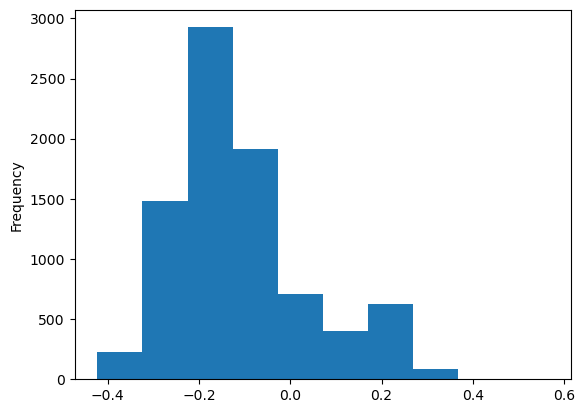

In [111]:
est = DML(
    model_y=RandomForestClassifier(),
    model_t=RandomForestClassifier(),
    model_final=RandomForestRegressor(),
    # model_final=StatsModelsLinearRegression(fit_intercept=False),
    # model_final = GradientBoostingRegressor(),
    discrete_treatment=True,
    discrete_outcome=True,
    mc_iters=10
)
# est = DRLearner(
#     model_regression=RandomForestClassifier(),
#     model_propensity=RandomForestClassifier(),
#     model_final=RandomForestRegressor(),
#     discrete_outcome=True,
#     random_state=12
# )
est.fit(Y=Y, T=T, X=X, W=X)

ite = est.effect(X=X).ravel()
pd.Series(ite).plot(kind='hist')

In [112]:
data.outcome

0       0
1       0
2       0
3       0
4       0
       ..
8370    1
8371    0
8372    0
8373    0
8374    0
Name: outcome, Length: 8375, dtype: int64

In [115]:
data['ite'] = ite
data.to_csv(path_or_buf='~/Desktop/EHR/EHR work/RdataFiles/BuildCohortDatasets/CleanedData/gramneg_modded_2017_2023_bacteremia_withCATEs.csv', sep='\t', index=False)

### Explainability / Interpretability ???

In [104]:
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

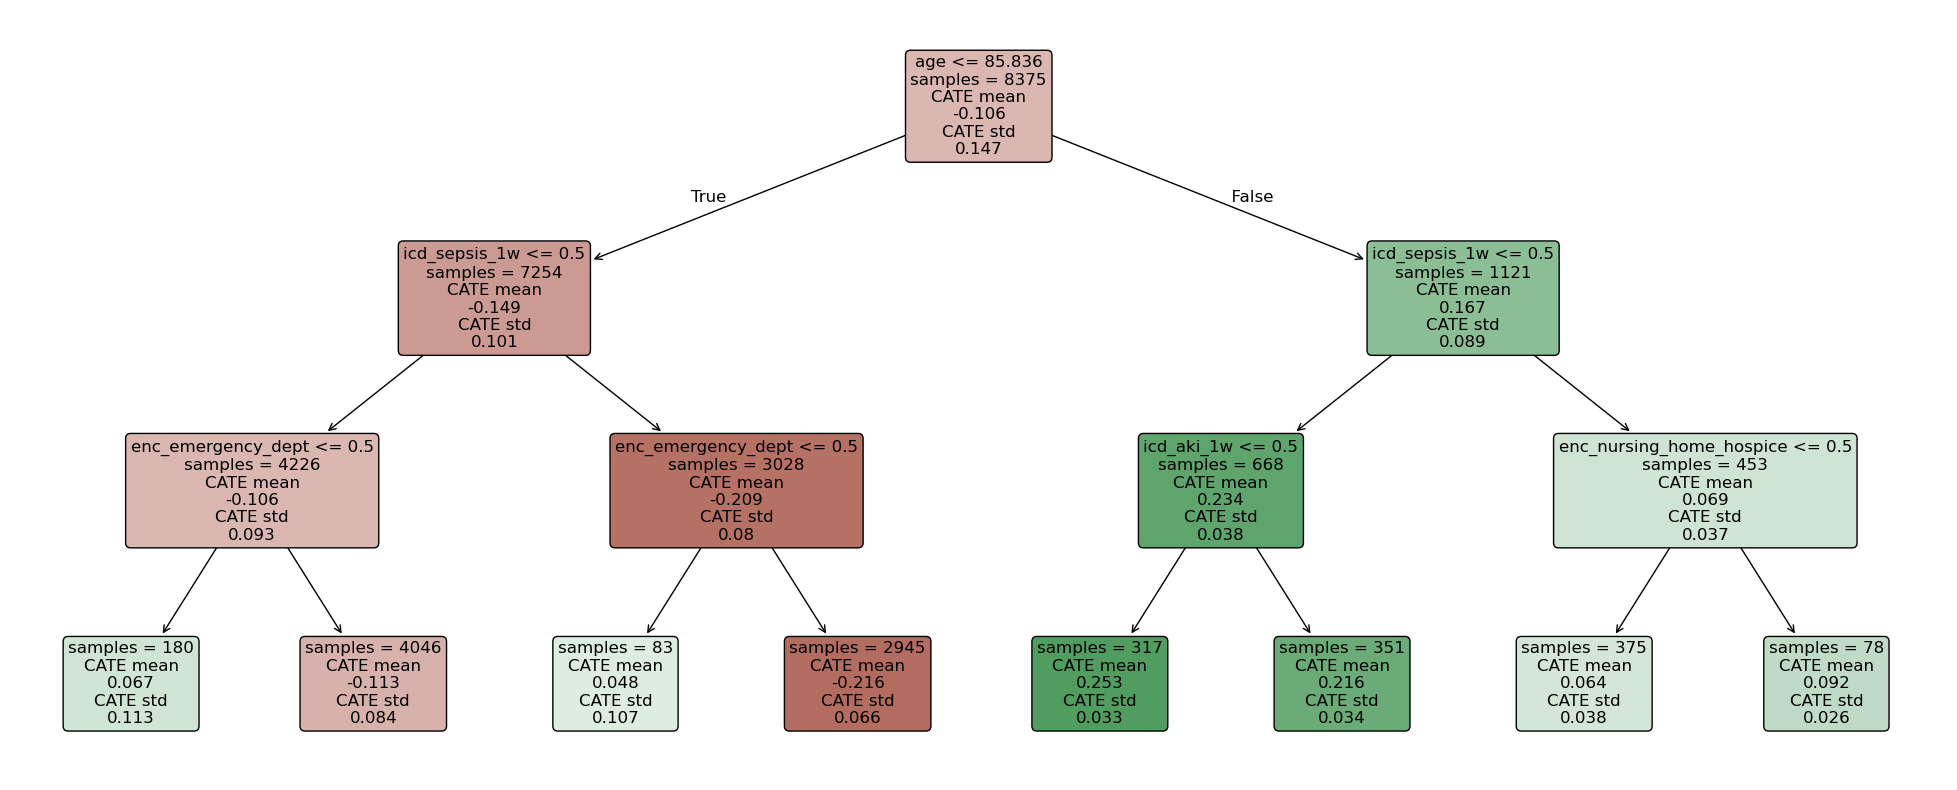

In [114]:
intrp = SingleTreeCateInterpreter(max_depth=3, min_samples_leaf=50)
intrp.interpret(est, X)
plt.figure(figsize=(25, 10))
intrp.plot(feature_names=X.columns, fontsize=12)

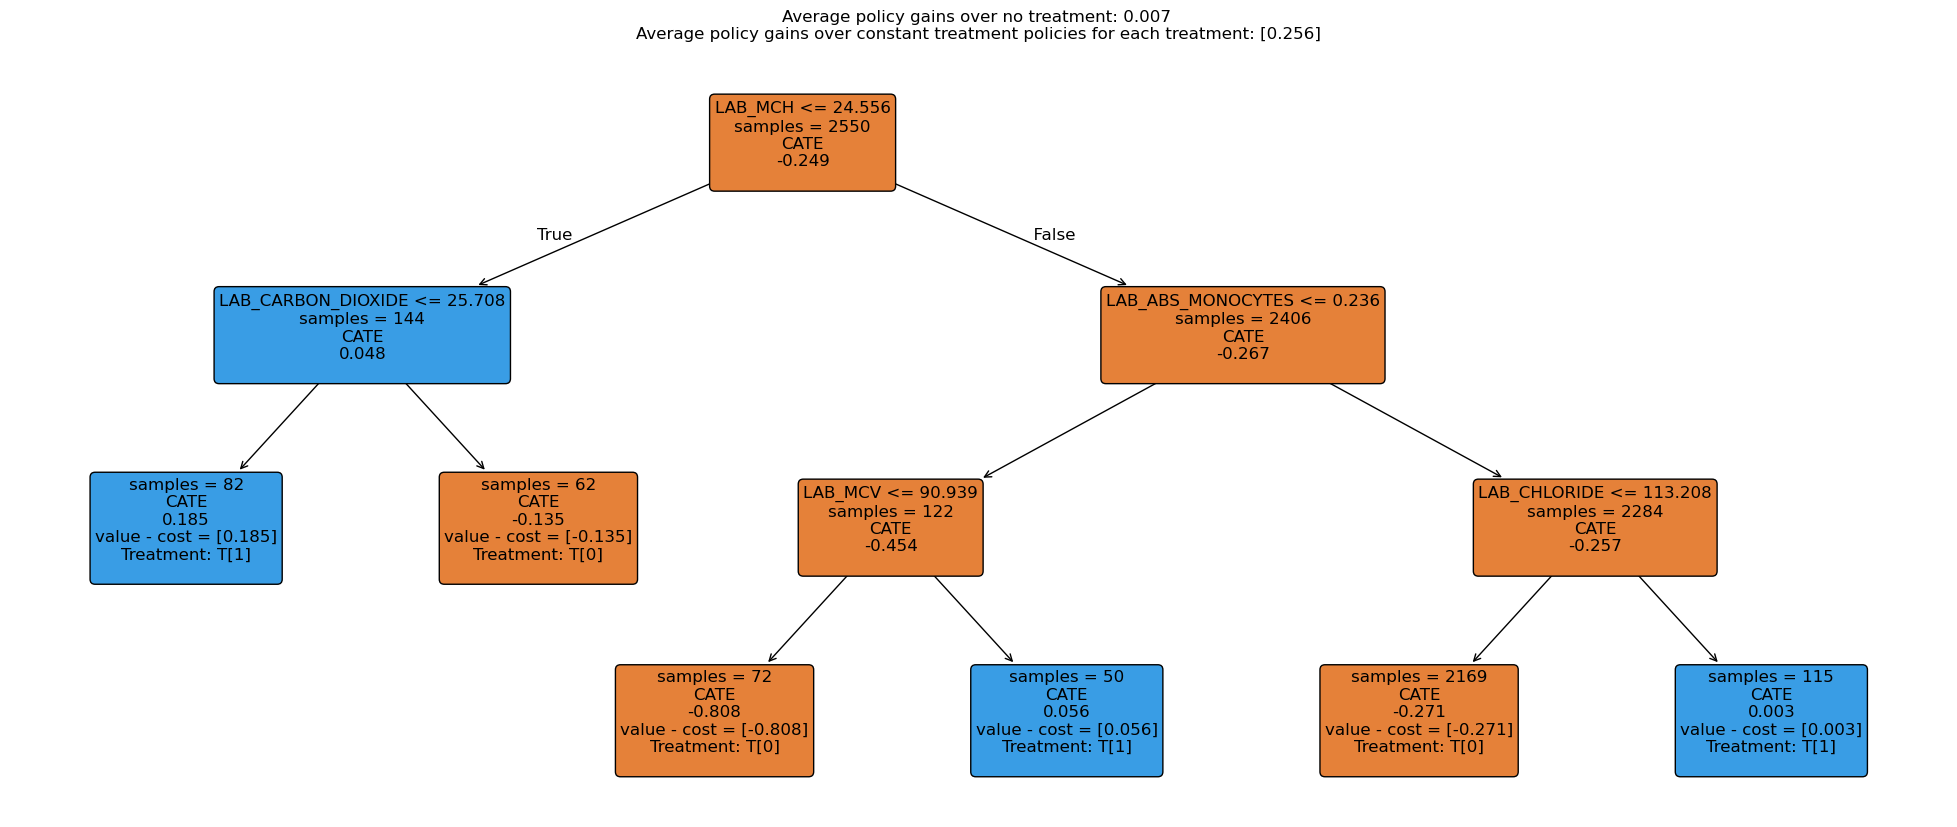

In [138]:
intrp = SingleTreePolicyInterpreter(max_depth=3, min_samples_leaf=50)
intrp.interpret(est, X, sample_treatment_costs=0.2)
plt.figure(figsize=(25, 10))
intrp.plot(feature_names=X.columns, fontsize=12)